In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import PiecewiseGQ2D_weights_points, SquareMesh2D_points, split_domain_boundary
from utils import s2_uniform_grid_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence
from model import ShallowReLUkSolver
from model import PouShallowReLUkSolver

In [2]:
def run_exp(k, m, l, nmin=6, nmax=13):
    x_train = SquareMesh2D_points(0,1,200)
    x_test = SquareMesh2D_points(0,1,150)

    if l == 0:
        # Global fitter
        neuron_num_arr= np.array([2**i for i in range(nmin, nmax)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = ShallowReLUkSolver(
                ws, bs, x_train, k=k, m1=m, m2=m)
            if fitter.n > 2500:
                break
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n)
            rel_errl2_arr.append(rel_errl2)
            print('num neuron : {:} - rel l2 : {:.4e}'.format(fitter.n, rel_errl2))
    else:
        neuron_num_arr= np.array([2**i for i in range(nmin, nmax)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = PouShallowReLUkSolver(
                ws, bs, x_train, l=l, k=k, m1=m, m2=m)
            if fitter.J * fitter.n > 2500:
                break 
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n*fitter.J)
            rel_errl2_arr.append(rel_errl2)
            print('local {:} num neuron : {:} - rel l2 : {:.4e}'.format(fitter.J, fitter.n*fitter.J, rel_errl2))

    return np.array(neuron_arr), np.array(rel_errl2_arr)

In [4]:
k = 4
m = 1
l_list = [0, 1, 2, 3]
neurons_list = []
errs_list = []
for l in l_list:
    neurons, errs = run_exp(k, m, l, 2, 13)
    neurons_list.append(neurons)
    errs_list.append(errs)

num neuron : 3 - rel l2 : 3.1441e+00
num neuron : 6 - rel l2 : 4.6174e+00
num neuron : 11 - rel l2 : 9.5010e+00
num neuron : 23 - rel l2 : 4.4167e-01
num neuron : 43 - rel l2 : 9.7610e-02
num neuron : 69 - rel l2 : 2.6209e-02
num neuron : 125 - rel l2 : 9.9708e-03
num neuron : 239 - rel l2 : 2.1130e-03
num neuron : 457 - rel l2 : 7.0377e-04
num neuron : 909 - rel l2 : 4.9742e-05
num neuron : 1809 - rel l2 : 1.4188e-05
local 4 num neuron : 12 - rel l2 : 1.8568e+00
local 4 num neuron : 24 - rel l2 : 2.7597e+00
local 4 num neuron : 44 - rel l2 : 1.6816e+00
local 4 num neuron : 92 - rel l2 : 3.7743e-02
local 4 num neuron : 172 - rel l2 : 1.4992e-02
local 4 num neuron : 276 - rel l2 : 4.5251e-03
local 4 num neuron : 500 - rel l2 : 1.3322e-03
local 4 num neuron : 956 - rel l2 : 9.8751e-04
local 4 num neuron : 1828 - rel l2 : 2.0564e-04
local 9 num neuron : 27 - rel l2 : 1.2636e+00
local 9 num neuron : 54 - rel l2 : 1.5674e+00
local 9 num neuron : 99 - rel l2 : 1.7926e+00
local 9 num neuron :

In [7]:
def plot_err_convergence_levels(relu_k, d, neuron_list, err_list, levels, title):
    """
    Plot L2 error convergence for multiple levels l.
    
    Parameters:
        relu_k : int
            Degree of ReLU (k)
        d : int
            Input dimension
        neuron_list : list of arrays
            Each element: actual_neuron_arr for one level l
        err_list : list of arrays
            Each element: mean_err_l2_arr for one level l
        levels : list
            List of level parameters corresponding to neuron_list / err_list
        title : str
            Plot title
    """
    plt.figure(figsize=(7,5))
    L2J = {1:4, 2:9, 3:25}

    for neurons, err, l in zip(neuron_list, err_list, levels):
        # compute reference line for this level (optional)
        if l == 0:
            optimal_rate = 1/2 + (2 * relu_k + 1)/(2*d)
            ref = err[0] * neurons[0]**optimal_rate * neurons**(-optimal_rate)
            plt.plot(neurons, ref, '--', label=f'slope = -{optimal_rate:.2f}')
            plt.plot(neurons, err, '.-', label=f'ReLU$^{relu_k}$', linewidth=2)
        else:
            plt.plot(neurons, err, '.-', label=f'J = {L2J[l]}, ReLU$^{relu_k}$', linewidth=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Number of neurons n")
    plt.ylabel("rel $L^2$ error")
    plt.title(title)
    plt.legend(loc="upper right") 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()


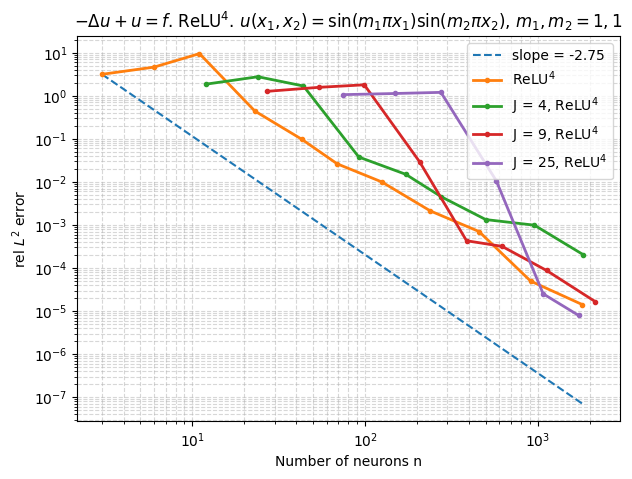

In [10]:
title = "$-\Delta u + u = f$. ReLU$^{}$. $u(x_1, x_2) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m, m)
plot_err_convergence_levels(k, 2, neurons_list, errs_list, l_list, title)

In [2]:
class PouShallowReLUkNetwork:
    def __init__(
        self, ws, bs, pts, k=1, l=1, sigma=0.01, m1=1, m2=1):
        
        self.n = ws.shape[0]
        self.d = ws.shape[1]
        self.k = k
        self.l = l
        self.sigma = sigma
        self.m1 = m1 
        self.m2 = m2
        self.pts = pts
        cntrs, rng = self.pou_init()
        self.cntrs, self.rng = cntrs, rng

        self.J = self.cntrs.shape[0]
        self.W = ws.unsqueeze(0).repeat(self.J, 1, 1)   # [J, n, d]
        self.b = bs.unsqueeze(0).repeat(self.J, 1)      # [J, n]

        pts_dom, pts_bd = split_domain_boundary(pts)
        self.pts_dom = pts_dom #.requires_grad_(True)
        self.pts_bd = pts_bd
    
    def map_unit(self, x):
        '''
        Inputs:
            x : (N, d)
            cntrs: (J, d)
            rng : float
        Returns:
            x_ : (N, J, d)
        '''
        x_ = (x.unsqueeze(0) - self.cntrs.unsqueeze(1) + self.rng)/(2 * self.rng)
        return x_
    
    def pou_init(self):
        rng = 1 / 2**(self.l)
        cntr_1d = torch.linspace(0, 1, 2**(self.l-1)+1).reshape(-1, 1)
        grid = list(itertools.product(cntr_1d, repeat=2)) # 2 for 2D input
        cntrs = torch.tensor(grid)
        return cntrs, rng

    def pou_extract(self, x):
        '''
        Inputs:
            x : (N, D) tensor
            cntrs : (J, D) tensor 
            rng : scalar (float or tensor)
            sigma : scalar (float or tensor)
        Returns:
            (J, N) tensor
        '''
        def phi(z):
            return 1 / (1 + torch.exp(-z))

        # Expand dimensions for broadcasting: (N,1,D) - (1,M,D) → (N,M,D)
        a = self.cntrs.unsqueeze(1) - self.rng
        b = self.cntrs.unsqueeze(1) + self.rng
        x_exp = x.unsqueeze(0)

        # Apply PoU formula over each dimension
        vals = phi((x_exp - a) / self.sigma) * phi((b - x_exp) / self.sigma)

        # Product over D → (N,M)
        return vals.prod(dim=2, keepdim=False)

    def feat_extract(self, x):
        pou_feat = self.pou_extract(x) # [J, N]
        x_ = self.map_unit(x)
        local_feats = []
        for j in range(self.J):
            feat = F.relu(x_[j] @ self.W[j].t() + self.b[j]) ** self.k
            local_feat = feat * pou_feat[j].unsqueeze(-1)
            local_feats.append(local_feat)
        return torch.hstack(local_feats)

    def lapfeat(self, x):
        """
        Analytic Laplacian of PoU-weighted ReLU^k features.
        Returns (N, J*n) matching feat_extract's column order.
        """
        eps = 1e-12
        beta = self.sigma  # PoU smoothness
        N, d = x.shape
        assert d == self.d == 2, "This implementation assumes 2D."

        # ---------- PoU: phi, grad_phi, lap_phi ----------
        # shapes: a,b -> (J,1,d); xj -> (1,N,d); broadcast -> (J,N,d)
        a = self.cntrs.unsqueeze(1) - self.rng
        b = self.cntrs.unsqueeze(1) + self.rng
        xj = x.unsqueeze(0)

        def sig(u): return torch.sigmoid(u)
        sL = sig((xj - a)/beta)           # left wall σ((x-a)/β)
        sR = sig((b - xj)/beta)           # right wall σ((b-x)/β)

        p   = sL * sR                      # per-dim PoU factors, (J,N,d)
        sL1 = (1.0/beta)  * sL * (1.0 - sL)
        sR1 = (-1.0/beta) * sR * (1.0 - sR)
        sL2 = (1.0/(beta**2)) * sL * (1.0 - sL) * (1.0 - 2.0*sL)
        sR2 = (1.0/(beta**2)) * sR * (1.0 - sR) * (1.0 - 2.0*sR)

        dp  = sL1 * sR + sL * sR1                         # ∂p/∂x_d
        d2p = sL2 * sR + 2.0*sL1*sR1 + sL * sR2           # ∂²p/∂x_d²

        phi = p.prod(dim=2)                               # (J,N)
        R = phi.unsqueeze(-1) / (p + eps)                 # (J,N,d) = ∏_{i≠d} p_i
        grad_phi = dp * R                                 # (J,N,d)
        lap_phi  = (d2p * R).sum(dim=2)                   # (J,N)

        # ---------- Local ReLU^k on unit-mapped coords ----------
        # map_unit: (J,N,d)
        x_u = self.map_unit(x)

        # z: (J,N,n) using batch matmul via einsum
        z = torch.einsum('jnd,jkd->jnk', x_u, self.W) + self.b[:, None, :]
        active = (z > 0).to(z.dtype)
        h = torch.relu(z)
        g = h ** self.k                                    # (J,N,n)

        # ∇g wrt original x: chain factor 1/(2*rng)
        if self.k >= 1:
            kfac = self.k * (z ** (self.k - 1)) * active  # (J,N,n)
            grad_g = kfac.unsqueeze(-1) * (self.W[:, None, :, :] / (2.0*self.rng))  # (J,N,n,d)
        else:
            grad_g = torch.zeros(z.shape + (d,), dtype=z.dtype, device=z.device)

        # Δg wrt original x: chain factor 1/(4*rng^2)
        if self.k >= 2:
            Wn2 = (self.W ** 2).sum(dim=2) / (4.0 * (self.rng ** 2))  # (J,n)
            lap_g = self.k * (self.k - 1) * (z ** (self.k - 2)) * active * Wn2[:, None, :]  # (J,N,n)
        else:
            lap_g = torch.zeros_like(z)

        # ---------- Δ(φ·g) = φΔg + 2∇φ·∇g + gΔφ ----------
        cross = 2.0 * (grad_phi.unsqueeze(2) * grad_g).sum(dim=3)          # (J,N,n)
        lap_f = phi.unsqueeze(2) * lap_g + cross + g * lap_phi.unsqueeze(2)  # (J,N,n)

        # Flatten to (N, J*n) in the same order as feat_extract's hstack over j
        return lap_f.permute(1, 0, 2).reshape(N, self.J * self.n)

    def target(self, x):
        z = torch.sin(self.m1 * pi*x[:,0:1])*torch.sin(self.m2 * pi*x[:,1:2])
        return z 

    def rhs(self, x):
        u = torch.sin(self.m1 * pi * x[:, 0:1]) * torch.sin(self.m2 * pi * x[:, 1:2])
        coeff = 1 + (self.m1 * pi) ** 2 + (self.m2 * pi) ** 2
        return coeff * u

    def assemble(self):
        gs = self.feat_extract(self.pts_dom)
        # lap_gs = self.lapfeat(gs, self.pts_dom)
        lap_gs = self.lapfeat(self.pts_dom)        
        A_dom = -lap_gs + gs
        b_dom = self.rhs(self.pts_dom)
        A_bd = self.feat_extract(self.pts_bd)
        b_bd = self.target(self.pts_bd)
        A = torch.concat([A_dom, A_bd])
        b = torch.concat([b_dom, b_bd])       
        return A, b

    def solve(self):
        A, b = self.assemble()

        c = 100.0 
        for i in range(len(A)):
            max_a = abs(A[i,:]).max()
            max_b = A[i,:].max()
            if max_a != max_b: 
                ratio = -c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
            else: 
                ratio = c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
        # alpha = scipy.linalg.lstsq(A.detach().numpy(),b.detach().numpy())[0]
        alpha = scipy.linalg.lstsq(A.numpy(),b.numpy())[0]
        self.alpha = torch.tensor(alpha)
        
    def forward(self, x):
        return self.feat_extract(x) @ self.alpha
    
    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()

num neuron : 12 - rel l2 : 1.8568e+00
num neuron : 24 - rel l2 : 2.7597e+00
num neuron : 44 - rel l2 : 1.6816e+00
num neuron : 92 - rel l2 : 3.7743e-02
num neuron : 172 - rel l2 : 1.4992e-02
num neuron : 276 - rel l2 : 4.5251e-03
num neuron : 500 - rel l2 : 1.3322e-03


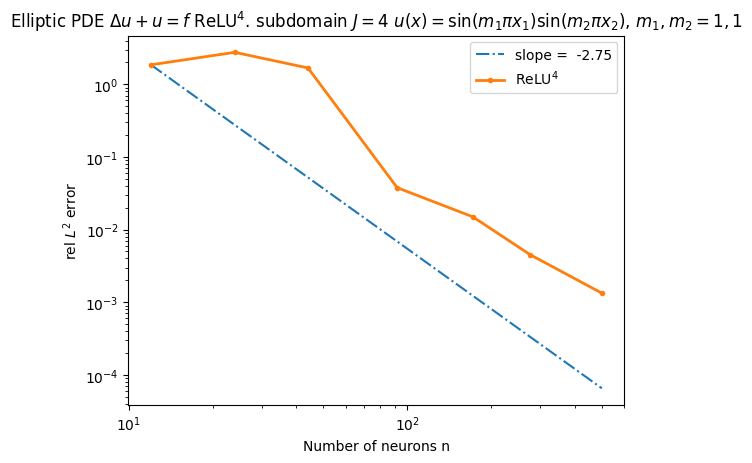

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
12 		 & 1.857e+00 &		 *  \\ \hline  

24 		 &  2.760e+00 &  		 -0.57  \\ \hline  

44 		 &  1.682e+00 &  		 0.82  \\ \hline  

92 		 &  3.774e-02 &  		 5.15  \\ \hline  

172 		 &  1.499e-02 &  		 1.48  \\ \hline  

276 		 &  4.525e-03 &  		 2.53  \\ \hline  

500 		 &  1.332e-03 &  		 2.06  \\ \hline  



In [5]:
x_train = SquareMesh2D_points(0,1,200)
x_test = SquareMesh2D_points(0,1,150)
k = 4
m1 = 1
m2 = 1
neuron_num_arr= np.array([2**i for i in range(2,9)]) 
neuron_arr = []
rel_errl2_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = s2_uniform_grid_init(n, k=k)
    model = PouShallowReLUkNetwork(
        ws, bs, x_train, l=1, k=k, m1=m1, m2=m2)
    if model.n * model.J > 3000:
        break 
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n*model.J)
    rel_errl2_arr.append(rel_errl2)
    print('num neuron : {:} - rel l2 : {:.4e}'.format(model.n*model.J, rel_errl2))
title = "Elliptic PDE $\Delta u + u = f$ ReLU$^{}$. subdomain $J={}$ $u(x) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, model.J, m1, m2)
plot_err_convergence(k,2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)